# Part C Dissertation - Modelling Networks with Complex Weights
## Coupled Cycle Example Plots
#### _(Candidate 1074092)_

In this notebook, we have most of the example plots from Section 3 of the dissertation. This includes the code to define nested, bridge coupled and vertex-sharing coupled cycles. 

We define a rough workflow for the generation of these graphs. <br>
•	Define the graph. This often includes creating a directed cycle (using my DiCycle function) and then adding the coupling edges. We write different functions for each coupling edge type. <br>
•	Calculate the magnetic Laplacian of the graph for varying $r$ values. We use the mLapN function (near the top of this notebook), substituting in $\theta = \frac{2\pi}{r}$. <br>
•	Plot the results on a graph. Though we are generally looking at small values of $r$ to be relevant to the clustering process, we sometimes show values up to $r = 60$ for illustrative purposes.

We have written functions to define the three main coupled cycle types analysed in Section 3.

In [1]:
import scipy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import networkx as nx

In [2]:
rng = np.random.default_rng(seed=None)

In [3]:
def mLapN(M, theta):
    M = M.toarray()
    n = np.shape(M)[0]
    #defines unweighted symmetric matrix
    W_s = (M + M.T) / 2

    #directional info matrix
    A = M
    A[(M > 0) & (M.T == 0)] = 1
    A[(M == 0) & (M.T > 0)] = -1
        
    #T matrix
    T = np.exp(1j * theta * A)
    #L matrix
    L = -W_s * T
    np.fill_diagonal(L, np.sum(W_s, axis=1))

    #Normalisation step, sets L_N = D^(-1/2) * L * D^(-1/2)
    D = np.sum(W_s, axis=1)
    normD = 1 / np.sqrt(D)
    L_N = (normD[:, None] * L) * normD[None, :]
    
    return L_N

In [4]:
def eig_qValuesN(A, qValues):
    #we work with q = theta / 2pi here
    sims = len(qValues)
    n = np.shape(A)[0]
    eigArray = np.empty((len(qValues), n + 1), dtype=float)
    thetaValues = np.array(qValues)*2*np.pi
    
    for i in range (0, sims):
        L_N = mLapN(A, thetaValues[i])
        eigs = np.linalg.eigvalsh(L_N)
        eigArray[i, 0] = qValues[i]
        for j in range(0, n):
            eigArray[i, j + 1] = eigs[j]
    return eigArray

In [5]:
def eig_rValuesN(A, rValues):
    sims = len(rValues)
    n = np.shape(A)[0]
    eigArray = np.empty((sims, n + 1), dtype=float)
    #note that we essentially set q = theta/2π, so for varying r as before we have r = 1/q
    thetaValues = (2*np.pi)/np.array(rValues)
    
    for i in range (0, sims):
        L_N = mLapN(A, thetaValues[i])
        eigs = np.linalg.eigvalsh(L_N)
        eigArray[i, 0] = rValues[i]
        for j in range(0, n):
            eigArray[i, j + 1] = eigs[j]
    return eigArray

In [6]:
def eigValues_plot(eigArray, n, idp, graphname):
    plt.figure(figsize=(6, 4))
    for i in range(0, n):
        plt.plot(eigArray[:, 0], eigArray[:, i + 1], label=rf"$\lambda_{{{i + 1}}}$")
    plt.xlabel(f"{idp}")
    plt.ylabel("λ")
    plt.title(f"λ (for varying {idp}) of {graphname}")
    plt.grid(True)
    plt.legend()
    plt.show()

In [7]:
def eigV_qplot(G, graphname, qValues):
    #pos = nx.shell_layout(G)
    #nx.draw(G, pos, with_labels=True, font_weight='bold', node_color='grey')
    A = nx.adjacency_matrix(G) 
    n = np.shape(G)[0]
    eigArrayN = eig_qValuesN(A, qValues)
    eigValues_plot(eigArrayN, n, "q", graphname)

In [8]:
def DiCycle(n):
    C_n = nx.cycle_graph(n, create_using=nx.DiGraph())
    C_n = nx.relabel_nodes(C_n, {0: n})
    return C_n

### Uncoupled n-cycles

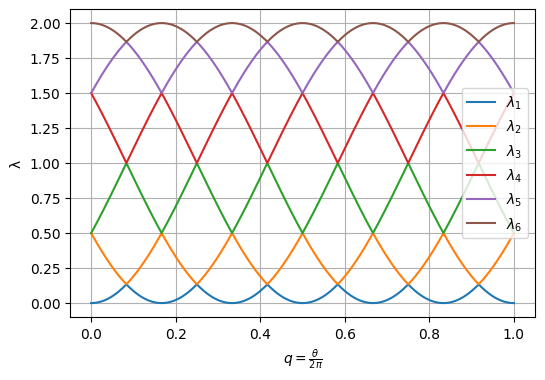

In [9]:
G = DiCycle(6)
qValues = [n / 1000 for n in range (0, 1001)]

A = nx.adjacency_matrix(G) 
n = np.shape(G)[0]
eigArray = eig_qValuesN(A, qValues)

plt.figure(figsize=(6, 4))
for i in range(0, n):
    plt.plot(eigArray[:, 0], eigArray[:, i + 1], label=rf"$\lambda_{{{i + 1}}}$")
plt.xlabel(r"$q=\frac{\theta}{2\pi}$")
plt.ylabel("λ")
#plt.title(f"λ (for varying {idp}) of {graphname}")
plt.grid(True)
plt.legend(loc = 'center right')
plt.show()

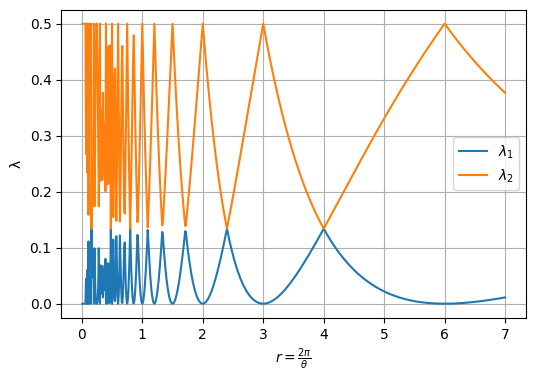

In [10]:
G = DiCycle(6)
rValues = [n / 100 for n in range(1, 701)]

A = nx.adjacency_matrix(G) 
n = np.shape(G)[0]
eigArray = eig_rValuesN(A, rValues)
eigInterest = [1, 2]

plt.figure(figsize=(6, 4))
for i in eigInterest:
    plt.plot(eigArray[:, 0], eigArray[:, i], label=rf"$\lambda_{{{i}}}$")
plt.xlabel(r"$r=\frac{2\pi}{\theta}$")
plt.ylabel("λ")
#plt.title(f"λ (for varying {idp}) of {graphname}")
plt.grid(True)
plt.legend()
plt.show()

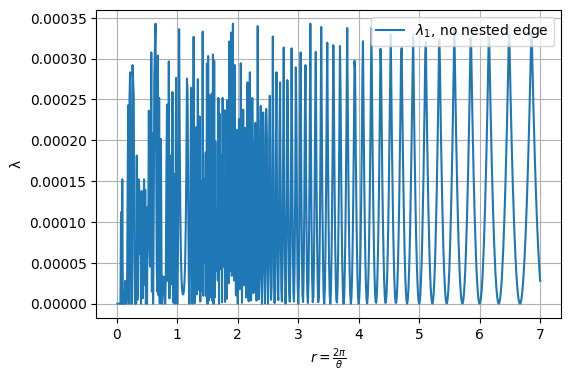

In [11]:
G = DiCycle(120)
rValues = [n / 100 for n in range(1, 701)]

A = nx.adjacency_matrix(G) 
n = np.shape(G)[0]
eigArray = eig_rValuesN(A, rValues)
eigInterest = [1]

plt.figure(figsize=(6, 4))
for i in eigInterest:
    plt.plot(eigArray[:, 0], eigArray[:, i], label=rf"$\lambda_{{{i}}}$, no nested edge")
plt.xlabel(r"$r=\frac{2\pi}{\theta}$")
plt.ylabel("λ")
#plt.title(f"λ (for varying {idp}) of {graphname}")
plt.grid(True)
plt.legend(loc='upper right')
plt.show()

### Nested cycles

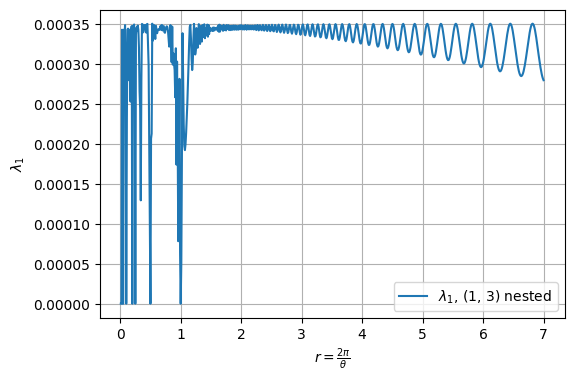

In [12]:
G = DiCycle(120)
rValues = [n / 100 for n in range(1, 701)]
list_of_edges = [(1, 3)]
G.add_edges_from(list_of_edges)

A = nx.adjacency_matrix(G) 
n = np.shape(G)[0]
eigArray = eig_rValuesN(A, rValues)
eigInterest = [1]

plt.figure(figsize=(6, 4))
for i in eigInterest:
    plt.plot(eigArray[:, 0], eigArray[:, i], label=rf"$\lambda_{{{i}}}$, (1, 3) nested")
plt.xlabel(r"$r=\frac{2\pi}{\theta}$")
plt.ylabel(r"$λ_1$")
#plt.title(f"λ (for varying {idp}) of {graphname}")
plt.grid(True)
plt.legend(loc='lower right')
plt.show()

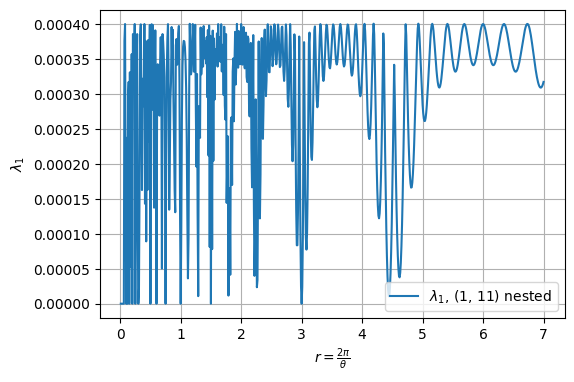

In [13]:
G = DiCycle(120)
rValues = [n / 100 for n in range(1, 701)]
list_of_edges = [(1, 11)]
G.add_edges_from(list_of_edges)

A = nx.adjacency_matrix(G) 
n = np.shape(G)[0]
eigArray = eig_rValuesN(A, rValues)
eigInterest = [1]

plt.figure(figsize=(6, 4))
for i in eigInterest:
    plt.plot(eigArray[:, 0], eigArray[:, i], label=rf"$\lambda_{{{i}}}$, (1, 11) nested")
plt.xlabel(r"$r=\frac{2\pi}{\theta}$")
plt.ylabel(r"$λ_1$")
#plt.title(f"λ (for varying {idp}) of {graphname}")
plt.grid(True)
plt.legend(loc='lower right')
plt.show()

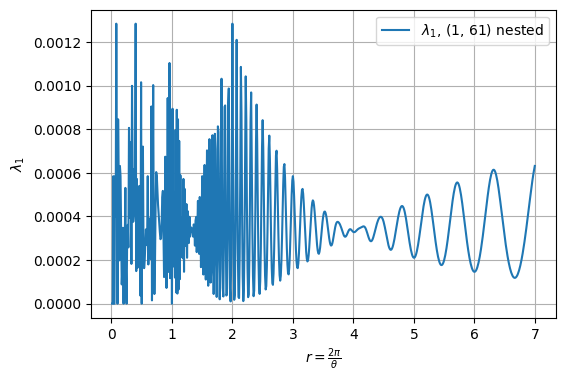

In [14]:
G = DiCycle(120)
rValues = [n / 100 for n in range(1, 701)]
list_of_edges = [(1, 61)]
G.add_edges_from(list_of_edges)

A = nx.adjacency_matrix(G) 
n = np.shape(G)[0]
eigArray = eig_rValuesN(A, rValues)
eigInterest = [1]

plt.figure(figsize=(6, 4))
for i in eigInterest:
    plt.plot(eigArray[:, 0], eigArray[:, i], label=rf"$\lambda_{{{i}}}$, (1, 61) nested")
plt.xlabel(r"$r=\frac{2\pi}{\theta}$")
plt.ylabel(r"$λ_1$")
#plt.title(f"λ (for varying {idp}) of {graphname}")
plt.grid(True)
plt.legend()
plt.show()

### Cycles coupled with symmetric bridges

In [15]:
def disjointDiCycle(n, m):
    C_n = nx.cycle_graph(n, create_using=nx.DiGraph())
    C_m = nx.cycle_graph(m, create_using=nx.DiGraph())
    disjCnm = nx.disjoint_union(C_n, C_m)
    mapping = {i: i + 1 for i in disjCnm.nodes()}
    disjCnm = nx.relabel_nodes(disjCnm, mapping)
    return disjCnm

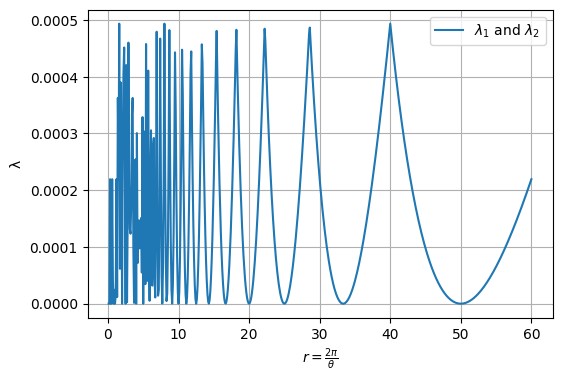

In [16]:
G = DiCycle(100)
rValues = [n / 10 for n in range(1, 601)]

A = nx.adjacency_matrix(G) 
n = np.shape(G)[0]
eigArray = eig_rValuesN(A, rValues)
eigInterest = [1]

plt.figure(figsize=(6, 4))
for i in eigInterest:
    plt.plot(eigArray[:, 0], eigArray[:, i], label=rf"$\lambda_{{{i}}}$ and $\lambda_{{{i+1}}}$")
plt.xlabel(r"$r=\frac{2\pi}{\theta}$")
plt.ylabel("λ")
#plt.title(f"λ (for varying {idp}) of {graphname}")
plt.grid(True)
plt.legend()
plt.show()

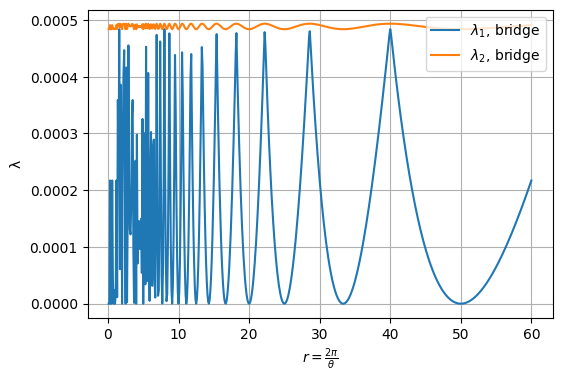

In [17]:
n = 100
m = 100
disjCnm = disjointDiCycle(n, m)
bridgeEdge = [(1, n+1), (n+1,1)]
bridgeCnm = disjCnm.copy()
bridgeCnm.add_edges_from(bridgeEdge)
rValues = [n / 10 for n in range(1, 601)]
G = bridgeCnm

A = nx.adjacency_matrix(G) 
n = np.shape(G)[0]
eigArray = eig_rValuesN(A, rValues)
eigInterest = [1, 2]

plt.figure(figsize=(6, 4))
for i in eigInterest:
    plt.plot(eigArray[:, 0], eigArray[:, i], label=rf"$\lambda_{{{i}}}$, bridge")
plt.xlabel(r"$r=\frac{2\pi}{\theta}$")
plt.ylabel("λ")
#plt.title(f"λ (for varying {idp}) of {graphname}")
plt.grid(True)
plt.legend(loc = 'upper right')
plt.show()

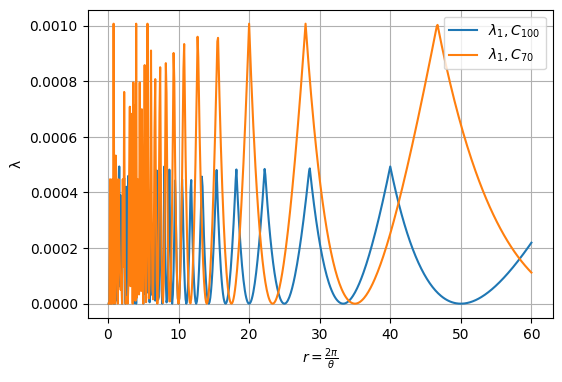

In [18]:
G = DiCycle(100)
rValues = [n / 10 for n in range(1, 601)]

A = nx.adjacency_matrix(G) 
n = np.shape(G)[0]
eigArray = eig_rValuesN(A, rValues)
eigInterest = [1]

plt.figure(figsize=(6, 4))
for i in eigInterest:
    plt.plot(eigArray[:, 0], eigArray[:, i], label=rf"$\lambda_{{{i}}}, C_{{100}}$")

G = DiCycle(70)
rValues = [n / 10 for n in range(1, 601)]

A = nx.adjacency_matrix(G) 
n = np.shape(G)[0]
eigArray = eig_rValuesN(A, rValues)
eigInterest = [1]
for i in eigInterest:
    plt.plot(eigArray[:, 0], eigArray[:, i], label=rf"$\lambda_{{{i}}}, C_{{70}}$")

plt.xlabel(r"$r=\frac{2\pi}{\theta}$")
plt.ylabel("λ")
#plt.title(f"λ (for varying {idp}) of {graphname}")
plt.grid(True)
plt.legend()
plt.show()

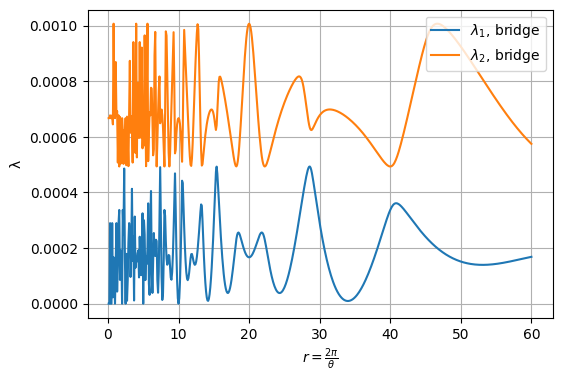

In [19]:
n = 100
m = 70
disjCnm = disjointDiCycle(n, m)
bridgeEdge = [(1, n+1), (n+1,1)]
bridgeCnm = disjCnm.copy()
bridgeCnm.add_edges_from(bridgeEdge)
qValues = [n / 1000 for n in range (0, 1001)]
G = bridgeCnm

A = nx.adjacency_matrix(G) 
n = np.shape(G)[0]
eigArray = eig_rValuesN(A, rValues)
eigInterest = [1, 2]

plt.figure(figsize=(6, 4))
for i in eigInterest:
    plt.plot(eigArray[:, 0], eigArray[:, i], label=rf"$\lambda_{{{i}}}$, bridge")
plt.xlabel(r"$r=\frac{2\pi}{\theta}$")
plt.ylabel("λ")
#plt.title(f"λ (for varying {idp}) of {graphname}")
plt.grid(True)
plt.legend(loc = 'upper right')
plt.show()

### Cycles coupled by directed bridge edges

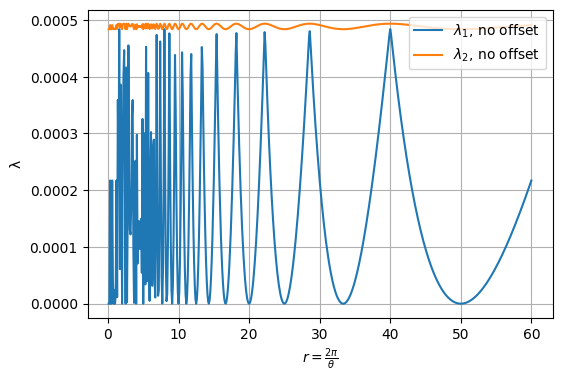

In [20]:
n = 100
m = 100
edge1 = (1, n + 1)
edge2 = (n+1, 1)
disjCnm = disjointDiCycle(n, m)
bridgeEdge = [edge1, edge2]
bridgeCnm = disjCnm.copy()
bridgeCnm.add_edges_from(bridgeEdge)
qValues = [n / 1000 for n in range (0, 1001)]
G = bridgeCnm

A = nx.adjacency_matrix(G) 
n = np.shape(G)[0]
eigArray = eig_rValuesN(A, rValues)
eigInterest = [1, 2]

plt.figure(figsize=(6, 4))
for i in eigInterest:
    plt.plot(eigArray[:, 0], eigArray[:, i], label=rf"$\lambda_{{{i}}}$, no offset")
plt.xlabel(r"$r=\frac{2\pi}{\theta}$")
plt.ylabel("λ")
#plt.title(f"λ (for varying {idp}) of {graphname}")
plt.grid(True)
plt.legend(loc = 'upper right')
plt.show()

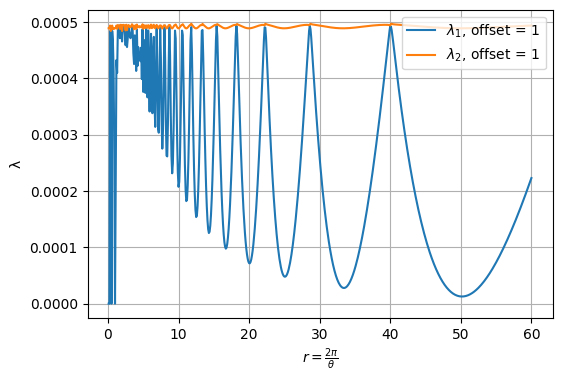

In [21]:
n = 100
m = 100
edge1 = (1, n + 2)
edge2 = (n+1, 1)
disjCnm = disjointDiCycle(n, m)
bridgeEdge = [edge1, edge2]
bridgeCnm = disjCnm.copy()
bridgeCnm.add_edges_from(bridgeEdge)
qValues = [n / 1000 for n in range (0, 1001)]
G = bridgeCnm

A = nx.adjacency_matrix(G) 
n = np.shape(G)[0]
eigArray = eig_rValuesN(A, rValues)
eigInterest = [1, 2]

plt.figure(figsize=(6, 4))
for i in eigInterest:
    plt.plot(eigArray[:, 0], eigArray[:, i], label=rf"$\lambda_{{{i}}}$, offset = 1")
plt.xlabel(r"$r=\frac{2\pi}{\theta}$")
plt.ylabel("λ")
#plt.title(f"λ (for varying {idp}) of {graphname}")
plt.grid(True)
plt.legend(loc = 'upper right')
plt.show()

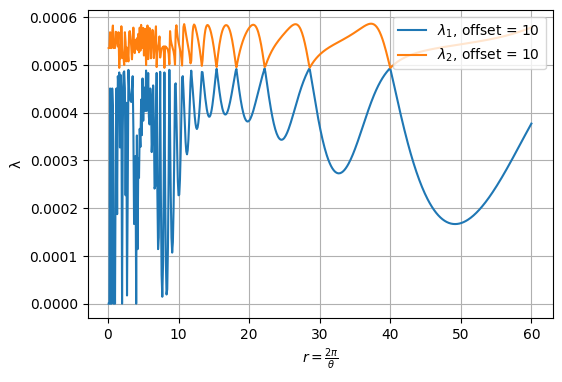

In [22]:
n = 100
m = 100
edge1 = (1, n + 1 + 10)
edge2 = (n+1, 1)
disjCnm = disjointDiCycle(n, m)
bridgeEdge = [edge1, edge2]
bridgeCnm = disjCnm.copy()
bridgeCnm.add_edges_from(bridgeEdge)
qValues = [n / 1000 for n in range (0, 1001)]
G = bridgeCnm

A = nx.adjacency_matrix(G) 
n = np.shape(G)[0]
eigArray = eig_rValuesN(A, rValues)
eigInterest = [1, 2]

plt.figure(figsize=(6, 4))
for i in eigInterest:
    plt.plot(eigArray[:, 0], eigArray[:, i], label=rf"$\lambda_{{{i}}}$, offset = 10")
plt.xlabel(r"$r=\frac{2\pi}{\theta}$")
plt.ylabel("λ")
#plt.title(f"λ (for varying {idp}) of {graphname}")
plt.grid(True)
plt.legend(loc = 'upper right')
plt.show()

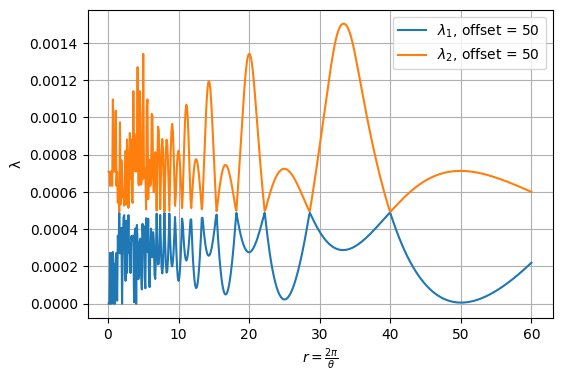

In [23]:
n = 100
m = 100
edge1 = (1, n + 1 + 50)
edge2 = (n+1, 1)
disjCnm = disjointDiCycle(n, m)
bridgeEdge = [edge1, edge2]
bridgeCnm = disjCnm.copy()
bridgeCnm.add_edges_from(bridgeEdge)
qValues = [n / 1000 for n in range (0, 1001)]
G = bridgeCnm

A = nx.adjacency_matrix(G) 
n = np.shape(G)[0]
eigArray = eig_rValuesN(A, rValues)
eigInterest = [1, 2]

plt.figure(figsize=(6, 4))
for i in eigInterest:
    plt.plot(eigArray[:, 0], eigArray[:, i], label=rf"$\lambda_{{{i}}}$, offset = 50")
plt.xlabel(r"$r=\frac{2\pi}{\theta}$")
plt.ylabel("λ")
#plt.title(f"λ (for varying {idp}) of {graphname}")
plt.grid(True)
plt.legend(loc = 'upper right')
plt.show()

### Cycles coupled by sharing a vertex
Note that we refer to these in the code as "tree" cycles, in keeping with Tian and Lambiotte in [19]. We call these vertex-sharing cycles in the final draft of the dissertation (the switch was made fairly late on).

In [24]:
def treeDiCycle(n, m):
    C_n = nx.cycle_graph(n, create_using=nx.DiGraph())
    C_m = nx.cycle_graph(m, create_using=nx.DiGraph())
    disjCnm = nx.disjoint_union(C_n, C_m)
    mapping = {i: i + 1 for i in disjCnm.nodes()}
    disjCnm = nx.relabel_nodes(disjCnm, mapping)
    treeCnm = nx.contracted_nodes(disjCnm, 1, n+m)
    return treeCnm

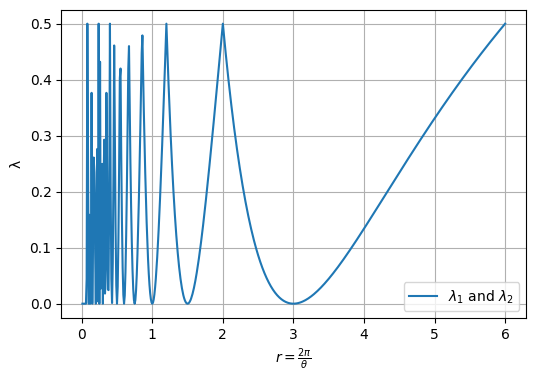

In [25]:
G = DiCycle(3)
rValues = [n / 100 for n in range(1, 601)]

A = nx.adjacency_matrix(G) 
n = np.shape(G)[0]
eigArray = eig_rValuesN(A, rValues)
eigInterest = [1]

plt.figure(figsize=(6, 4))
for i in eigInterest:
    plt.plot(eigArray[:, 0], eigArray[:, i], label=rf"$\lambda_{{{i}}}$ and $\lambda_{{{i+1}}}$")
plt.xlabel(r"$r=\frac{2\pi}{\theta}$")
plt.ylabel("λ")
#plt.title(f"λ (for varying {idp}) of {graphname}")
plt.grid(True)
plt.legend()
plt.show()

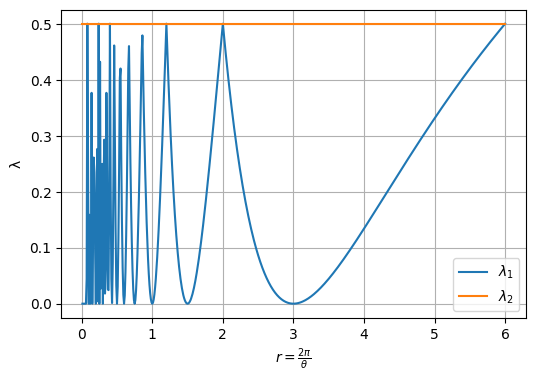

In [26]:
n = 3
m = 3
treeCnm = treeDiCycle(n, m)
rValues = [n / 100 for n in range(1, 601)]
G = treeCnm

A = nx.adjacency_matrix(G) 
n = np.shape(G)[0]
eigArray = eig_rValuesN(A, rValues)
eigInterest = [1, 2]

plt.figure(figsize=(6, 4))
for i in eigInterest:
    plt.plot(eigArray[:, 0], eigArray[:, i], label=rf"$\lambda_{{{i}}}$")
plt.xlabel(r"$r=\frac{2\pi}{\theta}$")
plt.ylabel("λ")
#plt.title(f"λ (for varying {idp}) of {graphname}")
plt.grid(True)
plt.legend()
plt.show()

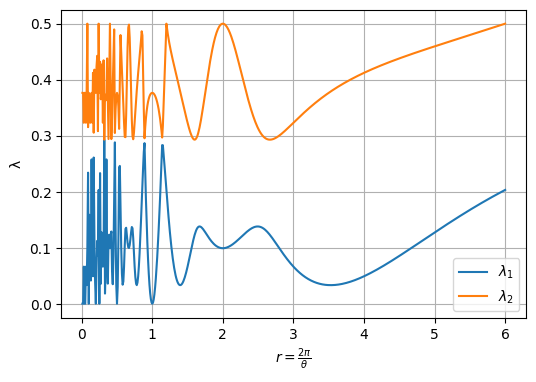

In [27]:
n = 3
m = 4
treeCnm = treeDiCycle(n, m)
rValues = [n / 100 for n in range(1, 601)]
G = treeCnm

A = nx.adjacency_matrix(G) 
n = np.shape(G)[0]
eigArray = eig_rValuesN(A, rValues)
eigInterest = [1, 2]

plt.figure(figsize=(6, 4))
for i in eigInterest:
    plt.plot(eigArray[:, 0], eigArray[:, i], label=rf"$\lambda_{{{i}}}$")
plt.xlabel(r"$r=\frac{2\pi}{\theta}$")
plt.ylabel("λ")
#plt.title(f"λ (for varying {idp}) of {graphname}")
plt.grid(True)
plt.legend()
plt.show()

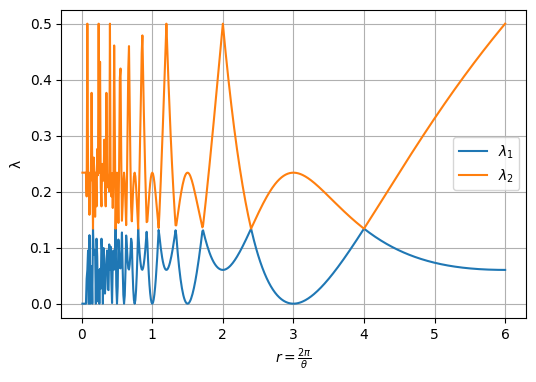

In [28]:
n = 3
m = 6
treeCnm = treeDiCycle(n, m)
rValues = [n / 100 for n in range(1, 601)]
G = treeCnm

A = nx.adjacency_matrix(G) 
n = np.shape(G)[0]
eigArray = eig_rValuesN(A, rValues)
eigInterest = [1, 2]

plt.figure(figsize=(6, 4))
for i in eigInterest:
    plt.plot(eigArray[:, 0], eigArray[:, i], label=rf"$\lambda_{{{i}}}$")
plt.xlabel(r"$r=\frac{2\pi}{\theta}$")
plt.ylabel("λ")
#plt.title(f"λ (for varying {idp}) of {graphname}")
plt.grid(True)
plt.legend()
plt.show()

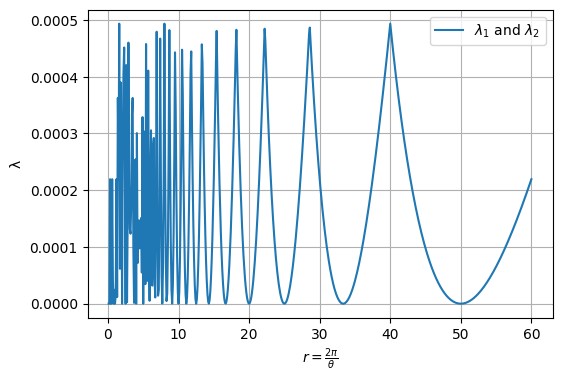

In [29]:
G = DiCycle(100)
rValues = [n / 10 for n in range(1, 601)]

A = nx.adjacency_matrix(G) 
n = np.shape(G)[0]
eigArray = eig_rValuesN(A, rValues)
eigInterest = [1]

plt.figure(figsize=(6, 4))
for i in eigInterest:
    plt.plot(eigArray[:, 0], eigArray[:, i], label=rf"$\lambda_{{{i}}}$ and $\lambda_{{{i+1}}}$")
plt.xlabel(r"$r=\frac{2\pi}{\theta}$")
plt.ylabel("λ")
#plt.title(f"λ (for varying {idp}) of {graphname}")
plt.grid(True)
plt.legend()
plt.show()

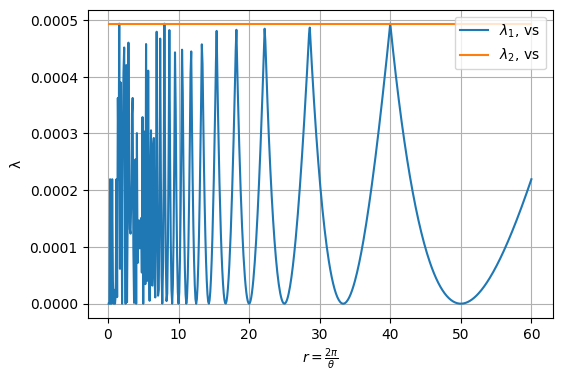

In [30]:
n = 100
m = 100
treeCnm = treeDiCycle(n, m)
rValues = [n / 10 for n in range(1, 601)]
G = treeCnm

A = nx.adjacency_matrix(G) 
n = np.shape(G)[0]
eigArray = eig_rValuesN(A, rValues)
eigInterest = [1, 2]

plt.figure(figsize=(6, 4))
for i in eigInterest:
    plt.plot(eigArray[:, 0], eigArray[:, i], label=rf"$\lambda_{{{i}}}$, vs")
plt.xlabel(r"$r=\frac{2\pi}{\theta}$")
plt.ylabel("λ")
#plt.title(f"λ (for varying {idp}) of {graphname}")
plt.grid(True)
plt.legend(loc = 'upper right')
plt.show()

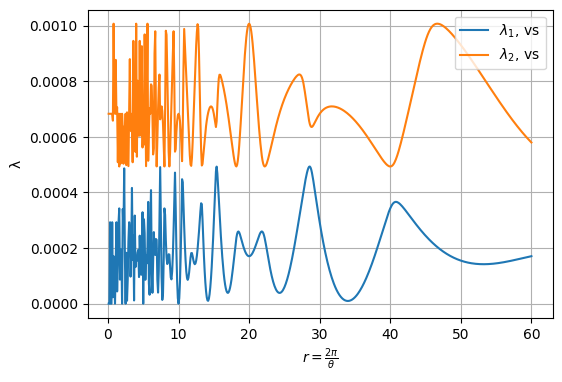

In [31]:
n = 100
m = 70
treeCnm = treeDiCycle(n, m)
rValues = [n / 10 for n in range(1, 601)]
G = treeCnm

A = nx.adjacency_matrix(G) 
n = np.shape(G)[0]
eigArray = eig_rValuesN(A, rValues)
eigInterest = [1, 2]

plt.figure(figsize=(6, 4))
for i in eigInterest:
    plt.plot(eigArray[:, 0], eigArray[:, i], label=rf"$\lambda_{{{i}}}$, vs")
plt.xlabel(r"$r=\frac{2\pi}{\theta}$")
plt.ylabel("λ")
#plt.title(f"λ (for varying {idp}) of {graphname}")
plt.grid(True)
plt.legend(loc = 'upper right')
plt.show()

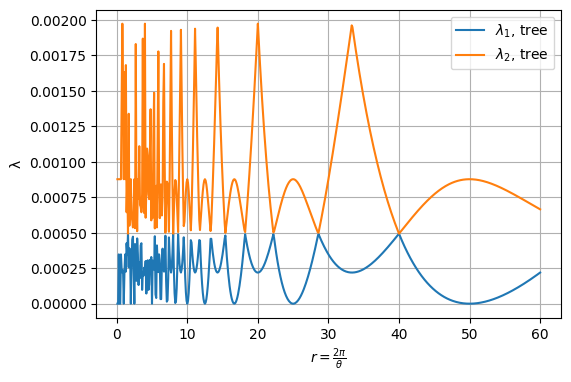

In [32]:
n = 100
m = 50
treeCnm = treeDiCycle(n, m)
rValues = [n / 10 for n in range(1, 601)]
G = treeCnm

A = nx.adjacency_matrix(G) 
n = np.shape(G)[0]
eigArray = eig_rValuesN(A, rValues)
eigInterest = [1, 2]

plt.figure(figsize=(6, 4))
for i in eigInterest:
    plt.plot(eigArray[:, 0], eigArray[:, i], label=rf"$\lambda_{{{i}}}$, tree")
plt.xlabel(r"$r=\frac{2\pi}{\theta}$")
plt.ylabel("λ")
#plt.title(f"λ (for varying {idp}) of {graphname}")
plt.grid(True)
plt.legend()
plt.show()

### Comparison between the symmetric bridge and the vertex-sharing coupled cycles
In the dissertation, we show that these graphs are structurally similar, and actually identical as we take $m, n \rightarrow \infty$.

In [33]:
n = 100
m = 70
rValues = [n / 10 for n in range(1, 601)]
disjCnm = disjointDiCycle(n, m)
bridgeEdge = [(1, n+1), (n+1,1)]
bridgeCnm = disjCnm.copy()
bridgeCnm.add_edges_from(bridgeEdge)
G = bridgeCnm

A = nx.adjacency_matrix(G) 
n = np.shape(G)[0]
eigArray1 = eig_rValuesN(A, rValues)
eigInterest = [1, 2]

treeCnm = treeDiCycle(n, m)
rValues = [n / 10 for n in range(1, 601)]
G = treeCnm

A = nx.adjacency_matrix(G) 
n = np.shape(G)[0]
eigArray2 = eig_rValuesN(A, rValues)
eigInterest = [1, 2]

eigDiff = np.zeros((len(rValues), len(eigInterest)))
for i in eigInterest:
    for j in range(0, len(rValues)):
        #bridge - tree
        eigDiff[j, i-1] = eigArray1[j, i] - eigArray2[j, i]

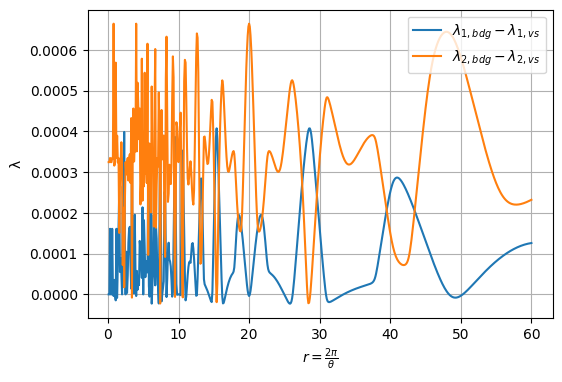

In [34]:
plt.figure(figsize=(6, 4))
for i in eigInterest:
    plt.plot(eigArray1[:, 0], eigDiff[:, i-1], label=rf"$\lambda_{{{i}, bdg}} - \lambda_{{{i}, vs}}$")
plt.xlabel(r"$r=\frac{2\pi}{\theta}$")
plt.ylabel("λ")
#plt.title(f"λ (for varying {idp}) of {graphname}")
plt.grid(True)
plt.legend(loc = 'upper right')
plt.show()

In [35]:
n = 100
m = 100
rValues = [n / 10 for n in range(1, 601)]
disjCnm = disjointDiCycle(n, m)
bridgeEdge = [(1, n+1), (n+1,1)]
bridgeCnm = disjCnm.copy()
bridgeCnm.add_edges_from(bridgeEdge)
G = bridgeCnm

A = nx.adjacency_matrix(G) 
n = np.shape(G)[0]
eigArray1 = eig_rValuesN(A, rValues)
eigInterest = [1, 2]

treeCnm = treeDiCycle(n, m)
rValues = [n / 10 for n in range(1, 601)]
G = treeCnm

A = nx.adjacency_matrix(G) 
n = np.shape(G)[0]
eigArray2 = eig_rValuesN(A, rValues)
eigInterest = [1, 2]

eigDiff = np.zeros((len(rValues), len(eigInterest)))
for i in eigInterest:
    for j in range(0, len(rValues)):
        #bridge - tree
        eigDiff[j, i-1] = eigArray1[j, i] - eigArray2[j, i]

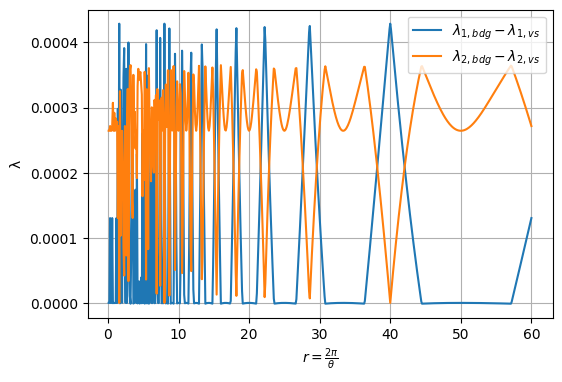

In [36]:
plt.figure(figsize=(6, 4))
for i in eigInterest:
    plt.plot(eigArray1[:, 0], eigDiff[:, i-1], label=rf"$\lambda_{{{i}, bdg}} - \lambda_{{{i}, vs}}$")
plt.xlabel(r"$r=\frac{2\pi}{\theta}$")
plt.ylabel("λ")
#plt.title(f"λ (for varying {idp}) of {graphname}")
plt.grid(True)
plt.legend(loc = 'upper right')
plt.show()